In [1]:
import pandas as pd
import numpy as np
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Loading TMDB Data Set

In [2]:
df = pd.read_csv("../data/TMDB_all_movies.csv")

In [3]:
print(df.shape)

(1233786, 30)


In [4]:
print(df.columns.tolist())

['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'cast', 'director', 'director_of_photography', 'writers', 'producers', 'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path', 'keywords', 'certification_us']


In [5]:
df['vote_count'].describe()

count    1.233786e+06
mean     2.236206e+01
std      3.668999e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      4.077400e+04
Name: vote_count, dtype: float64

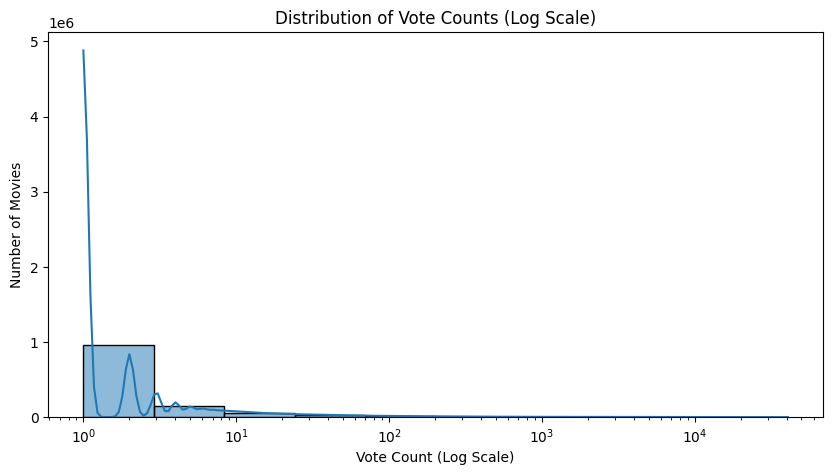

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram with a logarithmic x-axis (adding 1 to handle 0 vote counts)
plt.figure(figsize=(10, 5))
sns.histplot(df["vote_count"] + 1, log_scale=True, bins=10, kde=True)
plt.title("Distribution of Vote Counts (Log Scale)")
plt.xlabel("Vote Count (Log Scale)")
plt.ylabel("Number of Movies")
plt.show()

In [11]:
df['vote_count'].quantile([0.90, 0.95, 0.98, 0.99, 0.995, 0.999])

0.900       7.000
0.950      21.000
0.980      88.000
0.990     259.000
0.995     722.075
0.999    4419.000
Name: vote_count, dtype: float64

In [12]:
df["release_date"] = pd.to_datetime(df["release_date"])

In [39]:
# Filter for release dates up to the end of 2026
recent_movies_2026 = (
    df[(df["release_date"] <= "2026-7-17") & (df["vote_count"] > 7)]
    .sort_values(by="release_date", ascending=False)
    .head(20)[["title", "release_date", "vote_average", "vote_count", "imdb_votes", "imdb_rating"]]
    .reset_index(drop=True)
)

# Display the filtered table
recent_movies_2026

,title,release_date,vote_average,vote_count,imdb_votes,imdb_rating
0,Borderline,2026-07-17,6.938,8.0,308.0,3.5
1,Descendants: Wicked Wonderland,2026-07-16,7.575,153.0,2438.0,5.3
2,The Odyssey,2026-07-15,7.990,2837.0,408743.0,8.5
3,Hope,2026-07-15,8.100,22.0,1085.0,6.9
4,The Dreamed Adventure,2026-07-15,5.900,9.0,143.0,6.5
5,The Odyssey: The Making of an Epic,2026-07-14,6.400,14.0,351.0,6.5
6,Heartstopper Forever,2026-07-14,7.278,239.0,7395.0,7.0
7,Me Before Me,2026-07-11,6.528,18.0,147.0,5.2
8,Kung Fu Soccer,2026-07-11,5.850,20.0,579.0,5.6
9,Miguel Ángel Blanco: The 48 Hours That Changed...,2026-07-10,7.600,11.0,426.0,6.9


In [56]:
# Count movies matching all three conditions
count = df[
    (df["vote_average"] > 5)
    & (df["imdb_votes"] > 2000)
    & (df["vote_count"] > 200)
    & (df["release_date"] <= "2026-08-17")
    & (df["release_date"] >= "1900-01-01")
].shape[0]

print(f"Total matching movies: {count}")

Total matching movies: 13669


In [47]:
# Filter for release dates up to the end of 2026
recent_movies_2026 = (
    df[(df["vote_average"] > 5)
    & (df["imdb_votes"] > 2000)
    & (df["release_date"] <= "2026-08-17")
    & (df["release_date"] >= "1900-01-01")]
    .sort_values(by="release_date", ascending=True)
    .head(20)[["title", "release_date", "vote_average", "vote_count", "overview"]]
    .reset_index(drop=True)
)

# Display the filtered table
recent_movies_2026

,title,release_date,vote_average,vote_count,overview
0,The One-Man Band,1900-01-01,6.800,118.0,A band-leader has arranged seven chairs for th...
1,The Astronomer's Dream,1900-10-07,7.000,239.0,An astronomer has a terrifying dream.
2,Bluebeard,1901-07-25,6.300,67.0,A young woman becomes the eighth wife of the w...
3,The Big Swallow,1901-10-15,6.500,135.0,"A man, objecting to being filmed, comes closer..."
4,The Man with the Rubber Head,1901-12-01,7.200,171.0,A chemist carries out a bizarre experiment wit...
5,A Trip to the Moon,1902-06-15,7.882,2037.0,Professor Barbenfouillis and five of his colle...
6,Life of an American Fireman,1903-01-21,6.000,131.0,Porter's sequential continuity editing links s...
7,The Melomaniac,1903-05-18,6.600,88.0,The leader of a marching band demonstrates an ...
8,Alice in Wonderland,1903-05-19,6.000,129.0,This is the first movie version of the famous ...
9,The Kingdom of the Fairies,1903-07-25,6.900,91.0,"At the royal court, a prince is presenting the..."


In [57]:
df_filtered = df[
    ((df["vote_average"] > 6) & (df["vote_count"] > 500) & (df["imdb_votes"] > 5000)) |
    (df["release_date"] >= "2023-01-01")
].copy()

print(df_filtered.shape)

(203374, 30)


In [87]:
C = df['vote_average'].mean()
m = 700  # tune this — higher m means you trust vote_average less until a movie has more votes

def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

df['wr_score'] = df.apply(weighted_rating, axis=1)

In [111]:
df['wr_score'].describe()

count    1.233786e+06
mean     2.067817e+00
std      2.918923e-01
min      1.982782e+00
25%      2.022094e+00
50%      2.022094e+00
75%      2.029195e+00
max      8.579161e+00
Name: wr_score, dtype: float64

In [88]:
bayesian_df = df.sort_values(by="wr_score", ascending=False)

keyword = "hero"
matches = bayesian_df[
    bayesian_df["title"].str.contains(keyword, case=False, na=False)
]

matches[["title", "release_date", "vote_average", "vote_count"]]

,title,release_date,vote_average,vote_count
105734,Big Hero 6,2014-10-24,7.726,16754.0
426702,Dragon Ball Super: Super Hero,2022-06-11,7.900,3067.0
45,Hero,2002-12-19,7.505,2540.0
349891,The Boy and the Heron,2023-07-14,7.392,2726.0
412977,My Hero Academia: Heroes Rising,2019-12-20,8.100,1309.0
...,...,...,...,...
382378,Heroes,2012-03-30,0.000,1.0
328334,Heroine,2016-07-07,0.000,1.0
285318,Heroes in Love,2001-04-20,1.000,2.0
103399,Heroes: Lessons from the Book of Mormon,2014-04-30,0.500,2.0


In [102]:
bayesian_df = df.sort_values(by="wr_score", ascending=False)
bayesian_filtered_df = (
    bayesian_df[(bayesian_df["vote_count"] > 500)
    & (bayesian_df["release_date"] <= "2026-08-17")
    & (bayesian_df["release_date"] >= "1900-01-01")]
    .sort_values(by="release_date", ascending=False)
    .head(15000)[["title", "release_date", "vote_average", "vote_count", "wr_score"]]
    .reset_index(drop=True)
)

# Display the filtered table
bayesian_filtered_df

,title,release_date,vote_average,vote_count,wr_score
0,The Last House,2026-08-06,6.942,759.0,4.581524
1,The Devil's Mouth,2026-07-29,6.594,625.0,4.178653
2,Spider-Man: Brand New Day,2026-07-29,7.878,1825.0,6.254580
3,Avatar Aang: The Last Airbender,2026-07-24,9.251,864.0,6.015556
4,The Odyssey,2026-07-15,7.990,2837.0,6.808905
...,...,...,...,...,...
7952,The Kid,1921-01-21,8.100,2413.0,6.733301
7953,The Cabinet of Dr. Caligari,1920-02-27,7.928,1805.0,6.277647
7954,The Birth of a Nation,1915-03-08,5.942,600.0,3.831281
7955,The Great Train Robbery,1903-12-07,6.983,714.0,4.527106


In [101]:
# Search for any title containing a keyword
keyword = "spider"
matches = bayesian_filtered_df[
    bayesian_filtered_df["title"].str.contains(keyword, case=False, na=False)
]

matches[["title", "release_date", "vote_average", "vote_count"]]

,title,release_date,vote_average,vote_count
0,Spider-Man: Brand New Day,2026-07-29,7.878,1825.0
291,Spider-Man: Across the Spider-Verse,2023-05-31,8.342,9017.0
407,Spiderhead,2022-06-15,5.797,1749.0
460,Spider-Man: No Way Home,2021-12-15,7.940,22702.0
818,Spider-Man: Far From Home,2019-06-28,7.394,17400.0
911,Spider-Man: Into the Spider-Verse,2018-12-06,8.400,17639.0
936,The Girl in the Spider's Web,2018-10-25,6.200,1546.0
1208,Spider-Man: Homecoming,2017-07-05,7.333,23654.0
1812,The Amazing Spider-Man 2,2014-04-16,6.555,14579.0
2126,The Amazing Spider-Man,2012-06-23,6.752,18905.0


In [122]:
bayesian_new_filtered_df = (
    df[(df["wr_score"] >= 4) & (df["release_date"] >= "1900-01-01")]
    .sort_values(by="wr_score", ascending=False)
    .head(15000)                                   
    [["title", "release_date", "vote_average", "vote_count", "wr_score"]]
    .sort_values(by="release_date", ascending=True) 
    .reset_index(drop=True)
)

bayesian_new_filtered_df

,title,release_date,vote_average,vote_count,wr_score
0,A Trip to the Moon,1902-06-15,7.882,2037.0,6.383303
1,The Great Train Robbery,1903-12-07,6.983,714.0,4.527106
2,The Cabinet of Dr. Caligari,1920-02-27,7.928,1805.0,6.277647
3,The Phantom Carriage,1921-01-01,7.800,369.0,4.016525
4,The Kid,1921-01-21,8.100,2413.0,6.733301
...,...,...,...,...,...
7430,The Odyssey,2026-07-15,7.990,2837.0,6.808905
7431,Avatar Aang: The Last Airbender,2026-07-24,9.251,864.0,6.015556
7432,The Devil's Mouth,2026-07-29,6.594,625.0,4.178653
7433,Spider-Man: Brand New Day,2026-07-29,7.878,1825.0,6.254580


# Narrowed Down Data Set + Clean Up

In [360]:
bayesian_new_filtered_df = (
    df[(df["wr_score"] >= 4) & (df["release_date"] >= "1900-01-01")]
    .sort_values(by="wr_score", ascending=False)
    .head(15000)
    [[
        "title",
        "release_date",
        "vote_average",
        "vote_count",
        "wr_score",
        "overview",
        "genres",
        "keywords",
        "cast",
        "director",
        "poster_path",
        "popularity",
        "runtime",
        "tagline",
        "id"          # TMDB movie id: need this for poster fetching + as a stable unique key
    ]]
    .sort_values(by="release_date", ascending=True)
    .reset_index(drop=True)
)

bayesian_new_filtered_df

,title,release_date,vote_average,vote_count,wr_score,overview,genres,keywords,cast,director,poster_path,popularity,runtime,tagline,id
0,A Trip to the Moon,1902-06-15,7.882,2037.0,6.383303,Professor Barbenfouillis and five of his colle...,"Adventure, Science Fiction, Comedy",moon|based on novel or book|satire|astronomer|...,"Georges Méliès, Bleuette Bernon, François Lall...",Georges Méliès,/9o0v5LLFk51nyTBHZSre6OB37n2.jpg,5.3022,15.0,The first science fiction film!,775
1,The Great Train Robbery,1903-12-07,6.983,714.0,4.527106,After the train station clerk is assaulted and...,"Western, Crime, Action, Adventure",robbery|robber|dynamite|hold-up robbery|outlaw...,"Gilbert M. Anderson, John Manus Dougherty Sr.,...",Edwin S. Porter,/vEYr1sJR1dOFGXwXawpBN6hDRGF.jpg,2.2105,12.0,It electrified dad! It terrified mother! It wi...,5698
2,The Cabinet of Dr. Caligari,1920-02-27,7.928,1805.0,6.277647,"Francis, a young man, recalls in his memory th...","Drama, Horror, Thriller, Crime",insane asylum|black and white|silent film|unre...,"Werner Krauss, Conrad Veidt, Friedrich Fehér, ...",Robert Wiene,/myK9DeIsXWGKgUTZyGXg2IfFk0W.jpg,5.6498,77.0,You must become Caligari!,234
3,The Phantom Carriage,1921-01-01,7.800,369.0,4.016525,"An alcoholic, abusive ne'er-do-well is shown t...","Drama, Fantasy, Horror",new year's eve|based on novel or book|fight|po...,"Victor Sjöström, Hilda Borgström, Tore Svennbe...",Victor Sjöström,/pNqUCe3vF0yi2VTjyZSLqTwahlj.jpg,2.8151,108.0,Do the Dead Come Back? Can Your Soul Leave You...,58129
4,The Kid,1921-01-21,8.100,2413.0,6.733301,A tramp cares for a boy after he's abandoned a...,"Comedy, Drama",angel|suicide attempt|fistfight|slapstick come...,"Charlie Chaplin, Jackie Coogan, Carl Miller, E...",Charlie Chaplin,/A9NWYyn7eX0H9XIjaOvfWJ9mCGA.jpg,5.1821,68.0,6 reels of Joy.,10098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7430,The Odyssey,2026-07-15,7.990,2837.0,6.808905,"Odysseus, the legendary King of Ithaca, embark...","Adventure, Action, Fantasy",ship|trojan war|greek mythology|historical fic...,"Matt Damon, Tom Holland, Anne Hathaway, Robert...",Christopher Nolan,/5rhTDKUhPYvpdQIijFIs5VoWsON.jpg,869.7421,173.0,Defy the gods.,1368337
7431,Avatar Aang: The Last Airbender,2026-07-24,9.251,864.0,6.015556,"Avatar Aang, the world's last Airbender, learn...","Animation, Action, Adventure, Fantasy",martial arts|extinction|cultural identity|base...,"Eric Nam, Dave Bautista, Jessica Matten, Román...",Lauren Montgomery,/3sgnSfNT27Bx5O5ukr7B26mhEQq.jpg,135.4752,99.0,The legacy reawakens.,980431
7432,The Devil's Mouth,2026-07-29,6.594,625.0,4.178653,A group of college friends' Thailand adventure...,"Horror, Thriller",cave|animal attack|thailand|survival|creature|...,"Kathryn Newton, Lana Condor, Nico Hiraga, Gavi...",Jeff Wadlow,/lH8k9uCWYn2b2gsYleqYBDPbWa8.jpg,136.0477,106.0,Paradise has an appetite.,1481343
7433,Spider-Man: Brand New Day,2026-07-29,7.878,1825.0,6.254580,Fighting crime full-time as Spider-Man in a wo...,"Science Fiction, Action, Adventure",mind control|new york city|hero|mutation|secre...,"Tom Holland, Zendaya, Mark Ruffalo, Jon Bernth...",Destin Daniel Cretton,/iPOn6DinuVyLY17YM9mKuPofV08.jpg,1831.2906,145.0,A brand new day starts now.,969681


In [361]:
bayesian_new_filtered_df[["overview", "genres", "keywords", "cast", "director", "poster_path"]].isnull().sum()

overview         0
genres           1
keywords       107
cast            14
director         3
poster_path      3
dtype: int64

In [362]:
#Dropping null values
bayesian_new_filtered_df = bayesian_new_filtered_df.dropna(
    subset=["overview", "genres", "cast", "director", "poster_path"]
).reset_index(drop=True)

print(bayesian_new_filtered_df.shape)

(7417, 15)


In [363]:
bayesian_new_filtered_df["genres_list"] = bayesian_new_filtered_df["genres"].apply(
    lambda x: [g.strip() for g in x.split(",")] if pd.notna(x) else []
)

bayesian_new_filtered_df["cast_list"] = bayesian_new_filtered_df["cast"].apply(
    lambda x: [c.strip() for c in x.split(",")][:3] if pd.notna(x) else []  # top 3 actors
)

bayesian_new_filtered_df["keywords_list"] = bayesian_new_filtered_df["keywords"].apply(
    lambda x: [k.strip() for k in x.split("|")] if pd.notna(x) else []
)

bayesian_new_filtered_df["director_list"] = bayesian_new_filtered_df["director"].apply(
    lambda x: [x.strip()] if pd.notna(x) else []
)

In [364]:
bayesian_new_filtered_df[["title", "genres_list", "cast_list", "keywords_list", "director_list"]].head(3)

,title,genres_list,cast_list,keywords_list,director_list
0,A Trip to the Moon,"[Adventure, Science Fiction, Comedy]","[Georges Méliès, Bleuette Bernon, François Lal...","[moon, based on novel or book, satire, astrono...",[Georges Méliès]
1,The Great Train Robbery,"[Western, Crime, Action, Adventure]","[Gilbert M. Anderson, John Manus Dougherty Sr....","[robbery, robber, dynamite, hold-up robbery, o...",[Edwin S. Porter]
2,The Cabinet of Dr. Caligari,"[Drama, Horror, Thriller, Crime]","[Werner Krauss, Conrad Veidt, Friedrich Fehér]","[insane asylum, black and white, silent film, ...",[Robert Wiene]


# Stemming Movie Overview

In [365]:
# Collapsing multi-word names so it doesn't affect the vectorizing step
def collapse(lst):
    return [item.replace(" ", "") for item in lst]

bayesian_new_filtered_df["genres_collapsed"] = bayesian_new_filtered_df["genres_list"].apply(collapse)
bayesian_new_filtered_df["cast_collapsed"] = bayesian_new_filtered_df["cast_list"].apply(collapse)
bayesian_new_filtered_df["keywords_collapsed"] = bayesian_new_filtered_df["keywords_list"].apply(collapse)
bayesian_new_filtered_df["director_collapsed"] = bayesian_new_filtered_df["director_list"].apply(collapse)

In [366]:
# building the tags column, a one-space-separated string of info
bayesian_new_filtered_df["overview_words"] = bayesian_new_filtered_df["overview"].apply(lambda x: x.split())

def build_tags(row, genre_weight=4, keyword_weight=4, cast_weight=1, director_weight=2):
    tags = (
        row["overview_words"]
        + row["genres_collapsed"] * genre_weight
        + row["keywords_collapsed"] * keyword_weight
        + row["cast_collapsed"] * cast_weight
        + row["director_collapsed"] * director_weight
    )
    return " ".join(tags).lower()

bayesian_new_filtered_df["tags"] = bayesian_new_filtered_df.apply(build_tags, axis=1)

## Stemming + Vectorizing

In [367]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def stem(text):
    return " ".join([ps.stem(word) for word in text.split()])

bayesian_new_filtered_df["tags"] = bayesian_new_filtered_df["tags"].apply(stem)

In [368]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(bayesian_new_filtered_df["tags"]).toarray()

similarity = cosine_similarity(vectors)
print(similarity.shape)  

(7417, 7417)


### Single Movie Recommend Function

In [369]:
def recommend(movie_title):
    idx = bayesian_new_filtered_df[bayesian_new_filtered_df["title"] == movie_title].index
    if len(idx) == 0:
        print("Movie not found.")
        return
    idx = idx[0]
    distances = similarity[idx]
    movie_indices = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6] #not 0 since that's itself
    for i in movie_indices:
        print(bayesian_new_filtered_df.iloc[i[0]].title)

recommend("Project Hail Mary")  # or any title you know is in your filtered set

Spaceman
The Cloverfield Paradox
The Astronaut's Wife
2010
Mickey 17


### Problem right now is popularity bias (ex. Harry Potter franchise)

In [370]:
# capping per franchise
import re

movies_df = bayesian_new_filtered_df

def get_franchise_key(title, n_words=2):
    clean = re.sub(r'[^\w\s]', '', title.lower())  # strip punctuation
    words = clean.split()
    if words and words[0] in ("a", "an"):    # drop leading article so it doesn't skew the key
        words = words[1:]
    return " ".join(words[:n_words])

In [371]:
import random

def build_movie_dict(row, wildcard=False):
    d = {
        "id": int(row.id),
        "title": row.title,
        "poster_path": row.poster_path,
        "runtime": float(row.runtime) if pd.notna(row.runtime) else None,
        "vote_average": float(row.vote_average),
        "release_date": str(row.release_date),
        "genres": row.genres_list,
        "overview": row.overview,
        "tagline": row.tagline if pd.notna(row.tagline) else None,
        "cast": row.cast_list,
        "director": row.director_list,
    }
    if wildcard:
        d["wildcard"] = True
    return d

def recommend(movie_title, max_per_franchise=2, n_results=10, include_wildcard=True):
    idx = movies_df[movies_df["title"] == movie_title].index
    if len(idx) == 0:
        return None  
    idx = idx[0]

    query_franchise = get_franchise_key(movie_title)
    distances = similarity[idx]

    # Choosing from the top 150
    candidates = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:150]

    results = []
    franchise_counts = {}

    for i, score in candidates:
        row = movies_df.iloc[i]
        franchise = get_franchise_key(row.title)

        if franchise == query_franchise:
            franchise_counts[franchise] = franchise_counts.get(franchise, 0) + 1
            if franchise_counts[franchise] > max_per_franchise:
                continue

        results.append(build_movie_dict(row))
        if len(results) == n_results:
            break

    if include_wildcard and len(results) > 0:
        #Wildcard chosen randomly from 50-150
        wildcard_candidates = candidates[50:150]
        wildcard_pool = [
            i for i, score in wildcard_candidates
            if get_franchise_key(movies_df.iloc[i].title) != query_franchise
        ]

        if wildcard_pool:
            wc_idx = random.choice(wildcard_pool)
            row = movies_df.iloc[wc_idx]
            results[-1] = build_movie_dict(row, wildcard=True)

    return results

In [372]:
movies = recommend("Your Name.") 
for movie in movies:
        print(movie["title"])

The Anthem of the Heart
Rascal Does Not Dream of a Dreaming Girl
Steins;Gate: The Movie - Load Region of Déjà Vu
I Want to Eat Your Pancreas
The Quintessential Quintuplets Movie
Only Yesterday
A Whisker Away
Gabriel's Inferno: Part III
A Silent Voice: The Movie
All My Life


# Cold Start Recommendation Function

In [373]:
# Recommending from multiple liked movies
# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity

def get_coldstart_recommendations(movie_titles, max_per_franchise=2, n_results=10):
    indices = movies_df[movies_df["title"].isin(movie_titles)].index
    if len(indices) == 0:
        return None

    user_vector = vectors[indices].mean(axis=0).reshape(1, -1)
    sim_scores = cosine_similarity(user_vector, vectors)[0]

    candidates = sorted(list(enumerate(sim_scores)), reverse=True, key=lambda x: x[1])
    candidates = [c for c in candidates if c[0] not in indices][:150]

    results = []
    franchise_counts = {}
    seen_franchises_from_input = {get_franchise_key(t) for t in movie_titles}

    for i, score in candidates:
        row = movies_df.iloc[i]
        franchise = get_franchise_key(row.title)

        if franchise in seen_franchises_from_input:
            franchise_counts[franchise] = franchise_counts.get(franchise, 0) + 1
            if franchise_counts[franchise] > max_per_franchise:
                continue

        results.append(build_movie_dict(row))
        if len(results) == n_results:
            break

    return results

In [374]:
movies = get_coldstart_recommendations(["Inception", "The Matrix", "A Silent Voice: The Movie"])
for movie in movies:
        print(movie["title"])

The Matrix Reloaded
Dragon Ball Z: Fusion Reborn
Dragon Ball: Yo! Son Goku and His Friends Return!!
Dragon Ball Z: Broly - Second Coming
Dragon Ball Z: Resurrection 'F'
The Matrix Revolutions
Ghost in the Shell
Stand by Me Doraemon
Batman Ninja
Dragon Ball Super: Broly


# Watched Before Recommendation Function

In [375]:
def get_director_keys(row):
    # Extracts a set of normalized director names from a row.
    directors = row.get("director_list", [])
    if isinstance(directors, list):
        return {str(d).strip().lower() for d in directors if d}
    elif isinstance(directors, str):
        return {directors.strip().lower()}
    return set()

In [376]:
# Keyword post-boost only for watched-before recommendations
# Convert keyword lists into single space-separated strings
keyword_strings = movies_df["keywords_list"].apply(
    lambda x: " ".join([str(k).lower().replace(" ", "") for k in x])
    if isinstance(x, list)
    else ""
)

# 2. Vectorize keywords (min_df=2 ignores rare 1-off keywords to save memory)
keyword_vectorizer = CountVectorizer(binary=True, min_df=2)
keyword_vectors = keyword_vectorizer.fit_transform(keyword_strings)

In [377]:
def get_watched_before_recommendations(
    movie_titles, max_per_director=3, n_results=30, keyword_weight=0.7):
    
    indices = movies_df[movies_df["title"].isin(movie_titles)].index
    if len(indices) == 0:
        return None

    # 1. Content similarity (overview, cast, keywords)
    user_content_vec = vectors[indices].mean(axis=0).reshape(1, -1)
    content_sim = cosine_similarity(user_content_vec, vectors)[0]

    # 2. Genre similarity
    user_keyword_vec = np.asarray(keyword_vectors[indices].mean(axis=0)).reshape(1, -1)
    keyword_sim = cosine_similarity(user_keyword_vec, keyword_vectors)[0]

    # 3. Combine scores with weight (e.g., 60% general content + 40% genre match)
    combined_scores = (1 - keyword_weight) * content_sim + (keyword_weight) * keyword_sim

    candidates = sorted(
        list(enumerate(combined_scores)), reverse=True, key=lambda x: x[1]
    )
    candidates = [c for c in candidates if c[0] not in indices][:150]

    results = []
    director_counts = {}

    for i, score in candidates:
        row = movies_df.iloc[i]
        directors = get_director_keys(row)

        skip_movie = False
        for director in directors:
            if director_counts.get(director, 0) >= max_per_director:
                skip_movie = True
                break

        if skip_movie:
            continue

        # Increment counts for all directors credited on this movie
        for director in directors:
            director_counts[director] = director_counts.get(director, 0) + 1

        results.append(build_movie_dict(row))
        if len(results) == n_results:
            break

    return results

# Pickling

In [378]:
import pickle

# save the dataframe
with open('../models/movies_df.pkl', 'wb') as f:
    pickle.dump(movies_df, f)

# save the similarity matrix
with open('../models/similarity.pkl', 'wb') as f:
    pickle.dump(similarity, f)